In this one we take data for multiple thresholds

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [2]:
# Simulate the process
T = 10.0                       # Total simulation time.
tau_e = 0.06                   # Correlation decay parameter for the process.
tau_f = 0.005                  # Second correlation parameter.
dt = 0.05 * min(tau_e, tau_f)   # Time discretization step.
sigma = 1.0                    # Standard deviation of the process.
n = 1000                        # Number of trials

In [15]:
# Define a list of thresholds.
u_list = [0.0, 0.4]  # You can adjust these values as needed.

# We store the counts in a dictionary where each key is a threshold value.
observed_counts = {u: [] for u in u_list}

for i in range(n):
    t, x = utils.simulate_gaussian_process_fft(
        process.r_OU_noise, T, dt,
        sigma=sigma, tau=tau_e, kappa=tau_f/tau_e
    )
    # For each threshold, compute the count of upcrossings and store it.
    for u in u_list:
        count = len(utils.upcrossing_times(x=x, t=t, threshold=u))
        observed_counts[u].append(count)

observed_counts = {u: torch.tensor(counts, dtype=torch.float32)
                          for u, counts in observed_counts.items()}

In [16]:
# We'll create dictionaries for true_means and true_vars.
true_means = {}
true_vars = {}

for u in u_list:
    true_means[u] = observed_counts[u].mean()
    true_vars[u] = torch.var(observed_counts[u], correction=0)  # biased estimate

    print(f"Threshold u = {u}: Empirical mean = {true_means[u].item():.4f}, "
          f"Empirical variance = {true_vars[u].item():.4f}")

Threshold u = 0.0: Empirical mean = 91.2020, Empirical variance = 85.0532
Threshold u = 0.4: Empirical mean = 32.3320, Empirical variance = 62.2698


In [17]:
# # # alternatively set the targets to the analytical means and variance
# true_means = {}
# true_vars = {}

# for u in u_list:
#     model = formula.GaussianUpCrossingsDimless(r_func=process.r_OU_noise, u=u, tau=tau_e, kappa=tau_f/tau_e, sigma=sigma)
#     true_means[u] = model.upcrossing_mean(T)
#     true_vars[u] = model.upcrossing_variance(T)

#     print(f"Threshold u = {u}: Analytical mean = {true_means[u].item():.4f}, "
#           f"Analytical variance = {true_vars[u].item():.4f}")


Initial parameters:
tau_e: 0.100000
tau_f: 0.050000
kappa: 0.500000
sigma: 2.0
Epoch    0: Loss = 6110.4245, tau_e = 0.100000, tau_f = 0.050000, kappa = 0.500000, sigma = 2.000000
Epoch  100: Loss = 1987.9321, tau_e = 0.036681, tau_f = 0.017721, kappa = 0.483105, sigma = 1.298248
Epoch  200: Loss = 444.8972, tau_e = 0.025791, tau_f = 0.009174, kappa = 0.355684, sigma = 0.610354
Epoch  300: Loss = 193.8442, tau_e = 0.036350, tau_f = 0.007067, kappa = 0.194415, sigma = 0.765146
Epoch  400: Loss = 42.3233, tau_e = 0.050017, tau_f = 0.005791, kappa = 0.115773, sigma = 0.939709
Epoch  500: Loss = 20.1900, tau_e = 0.057520, tau_f = 0.005412, kappa = 0.094092, sigma = 1.024396
Epoch  600: Loss = 19.0386, tau_e = 0.059529, tau_f = 0.005333, kappa = 0.089579, sigma = 1.045968
Epoch  700: Loss = 19.0079, tau_e = 0.059878, tau_f = 0.005319, kappa = 0.088839, sigma = 1.049670
Epoch  800: Loss = 19.0071, tau_e = 0.059922, tau_f = 0.005318, kappa = 0.088747, sigma = 1.050133
Epoch  900: Loss = 19.00

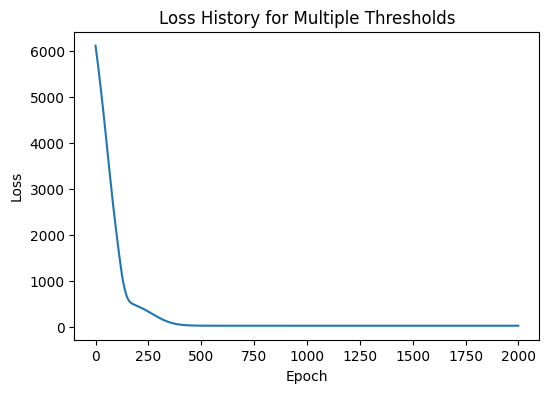

In [18]:
# Set up parameters for optimization.
# We optimize log-parameters so that their exponentiation guarantees positivity.
log_tau_e = torch.tensor(np.log(0.1), dtype=torch.float64, requires_grad=True)
log_tau_f = torch.tensor(np.log(0.05), dtype=torch.float64, requires_grad=True)
log_sigma = torch.tensor(np.log(2.0), dtype=torch.float64, requires_grad=True)

print("Initial parameters:")
print(f"tau_e: {torch.exp(log_tau_e).item():.6f}")
print(f"tau_f: {torch.exp(log_tau_f).item():.6f}")
print(f"kappa: {(torch.exp(log_tau_f)/torch.exp(log_tau_e)).item():.6f}")
print(f"sigma: {torch.exp(log_sigma).item()}")

# Choose an optimizer.
optimizer = torch.optim.Adam([log_tau_e, log_tau_f, log_sigma], lr=1e-2)

num_epochs = 2000
loss_history = []

# %% Optimization loop over multiple thresholds.
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Convert log parameters to actual parameters.
    tau_e_est = torch.exp(log_tau_e)
    tau_f_est = torch.exp(log_tau_f)
    sigma_est = torch.exp(log_sigma)
    kappa_est = tau_f_est / tau_e_est  # kappa = tau_f / tau_e.
    
    loss_total = 0.0
    # Loop over thresholds using the dictionary keys.
    for u in u_list:
        # Instantiate the model for threshold u.
        model_est = formula.GaussianUpCrossingsDimless(
            r_func=process.r_OU_noise,
            u=u,
            tau=tau_e_est,
            kappa=kappa_est,
            sigma=sigma_est
        )
        # Compute the predicted mean and variance over time T.
        mean_est = model_est.upcrossing_mean(T)
        # var_est = model_est.upcrossing_variance(T)
        var_est = model_est.upcrossing_variance_CLT(T)
        
        # Get the empirical statistics for the current threshold.
        true_mean = true_means[u]
        true_var = true_vars[u]
        
        # Sum the squared errors for the mean and variance.
        # nll = 0.5 * torch.log(2 * torch.pi * var_est) + 0.5 * ((observed_counts - mean_est)**2) / var_est
        # loss_total += nll.mean()  # Sum over all trials.
        loss_total += (mean_est - true_mean) ** 2 + (var_est - true_var) ** 2

    # Average the loss over the thresholds.
    loss_total = loss_total / len(u_list)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d}: Loss = {loss_total.item():.4f}, "
              f"tau_e = {tau_e_est.item():.6f}, tau_f = {tau_f_est.item():.6f}, "
              f"kappa = {(tau_f_est.item()/tau_e_est.item()):.6f}, sigma = {sigma_est.item():.6f}")
    
    loss_total.backward()
    optimizer.step()
    loss_history.append(loss_total.item())

print("Optimization complete!")
print("Estimated parameters:")
print(f"tau_e: {torch.exp(log_tau_e).item():.6f}")
print(f"tau_f: {torch.exp(log_tau_f).item():.6f}")
print(f"sigma: {torch.exp(log_sigma).item()}")

# %% Plot loss history.
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss History for Multiple Thresholds")
plt.show()

In [20]:
# Compare simulation and analytical statistics for each threshold.
print("\nAnalytical vs. Empirical statistics per threshold:")
for u in u_list:
    model_est = formula.GaussianUpCrossingsDimless(
        r_func=process.r_OU_noise,
        u=u,
        tau=tau_e_est,
        kappa=kappa_est,
        sigma=sigma_est
    )
    mean_est = model_est.upcrossing_mean(T)
    var_est = model_est.upcrossing_variance(T)
    print(f"\nThreshold u = {u}:")
    print(f"  Empirical mean = {true_means[u].item():.4f}, Analytical mean = {mean_est:.4f}")
    print(f"  Empirical variance = {true_vars[u].item():.4f}, Analytical variance = {var_est:.4f}")


Analytical vs. Empirical statistics per threshold:

Threshold u = 0.0:
  Empirical mean = 91.2020, Analytical mean = 89.1561
  Empirical variance = 85.0532, Analytical variance = 87.4887

Threshold u = 0.4:
  Empirical mean = 32.3320, Analytical mean = 36.6134
  Empirical variance = 62.2698, Analytical variance = 58.9960
